In [ ]:
import os
from google.colab import userdata  # Colab Secrets (key icon in the sidebar) - never hardcode credentials

# Kaggle credentials (stored in Colab Secrets)
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')

# تحميل الداتا سيت
!kaggle datasets download -d murtadhayaseen/arabic-fake-news-dataset-afnd

# فك ضغط الملف
!unzip arabic-fake-news-dataset-afnd.zip

Dataset URL: https://www.kaggle.com/datasets/murtadhayaseen/arabic-fake-news-dataset-afnd
License(s): unknown
100% 466M/466M [00:03<00:00, 123MB/s]

Archive:  arabic-fake-news-dataset-afnd.zip
  inflating: AFND/Dataset/source_1/scraped_articles.json  
  inflating: AFND/Dataset/source_10/scraped_articles.json  
  inflating: AFND/Dataset/source_100/scraped_articles.json  
  inflating: AFND/Dataset/source_101/scraped_articles.json  
  inflating: AFND/Dataset/source_102/scraped_articles.json  
  inflating: AFND/Dataset/source_103/scraped_articles.json  
  inflating: AFND/Dataset/source_104/scraped_articles.json  
  inflating: AFND/Dataset/source_105/scraped_articles.json  
  inflating: AFND/Dataset/source_106/scraped_articles.json  
  inflating: AFND/Dataset/source_107/scraped_articles.json  
  inflating: AFND/Dataset/source_108/scraped_articles.json  
  inflating: AFND/Dataset/source_109/scraped_articles.json  
  inflating: AFND/Dataset/source_11/scraped_articles.json  
  inflating: AFND/

In [ ]:
import pandas as pd
import json
import glob

# تحديد مسار المجلد الرئيسي للبيانات
path = 'AFND/Dataset'
all_files = glob.glob(path + "/*/scraped_articles.json")

li = []

# قراءة كل ملف json وتجميعه
for filename in all_files:
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
        # تحويل القائمة لجدول وإضافتها للقائمة الرئيسية
        temp_df = pd.DataFrame(data)
        li.append(temp_df)

# دمج كل الجداول في جدول واحد كبير
df = pd.concat(li, axis=0, ignore_index=True)

# عرض معلومات سريعة عن الجدول
print(f"تم تحميل {len(df)} خبر بنجاح!")
df.head()

تم تحميل 606912 خبر بنجاح!


,articles
0,{'title': 'بلحيمر:”أخطاء كثيرة عرفها تسيير ملف...
1,{'title': 'هذا هو البروتوكول الصحي الخاص بالحم...
2,{'title': 'تراجع ملحوظ في عدد الإصابات الجديدة...
3,{'title': 'بوقادوم يترأس اجتماع مجلس السلم وال...
4,{'title': 'برنامج اليوم الرابع من الحملة الانت...


In [ ]:
import pandas as pd
import json
import glob

# 1. تحميل المصادر
with open('AFND/sources.json', 'r', encoding='utf-8') as f:
    sources_data = json.load(f)

# تحويل القاموس لجدول (الـ Key هو الـ source_id والـ Value هو الـ label)
sources_df = pd.DataFrame(list(sources_data.items()), columns=['source_id', 'label'])

# تنظيف الـ source_id عشان يصير رقم بس (نشيل كلمة source_)
sources_df['source_id'] = sources_df['source_id'].str.replace('source_', '').astype(str)

# 2. تجميع كل الأخبار
all_files = glob.glob('AFND/Dataset/*/scraped_articles.json')
li = []
for filename in all_files:
    s_id = filename.split('/')[-2].replace('source_', '')
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)
            t_df = pd.DataFrame(data)

            if 'articles' in t_df.columns:
                expanded = pd.json_normalize(t_df['articles'])
                t_df = pd.concat([t_df.drop('articles', axis=1), expanded], axis=1)

            t_df['source_id'] = str(s_id)
            li.append(t_df)
    except:
        continue

df_all = pd.concat(li, axis=0, ignore_index=True)
df_all['source_id'] = df_all['source_id'].astype(str)

# 3. الربط النهائي
df_final = df_all.merge(sources_df, on='source_id', how='inner')

# 4. التنظيف والعرض
df_final.dropna(subset=['text', 'label'], inplace=True)

print("✅ تم الربط بنجاح أخيراً!")
print(f"إجمالي الأخبار: {len(df_final)}")
print("\nتوزيع الأخبار:")
print(df_final['label'].value_counts())

df = df_final.copy()
print(f"\n✅ الداتا جاهزة باسم df: {len(df)} خبر")

df_final[['title', 'label']].head()

✅ تم الربط بنجاح أخيراً!
إجمالي الأخبار: 606912

توزيع الأخبار:
label
undecided       232369
credible        207310
not credible    167233
Name: count, dtype: int64

✅ الداتا جاهزة باسم df: 606912 خبر


,title,label
0,بلحيمر:”أخطاء كثيرة عرفها تسيير ملف استيراد وت...,credible
1,هذا هو البروتوكول الصحي الخاص بالحملة الإنتخاب...,credible
2,تراجع ملحوظ في عدد الإصابات الجديدة بكورونا,credible
3,بوقادوم يترأس اجتماع مجلس السلم والأمن للإتحاد...,credible
4,برنامج اليوم الرابع من الحملة الانتخابية لتشري...,credible


📊 معلومات الداتا:
عدد الأخبار الكلي: 606912
الأعمدة الموجودة: ['title', 'text', 'published date', 'source_id', 'label']

📈 توزيع الأخبار:
label
undecided       232369
credible        207310
not credible    167233
Name: count, dtype: int64


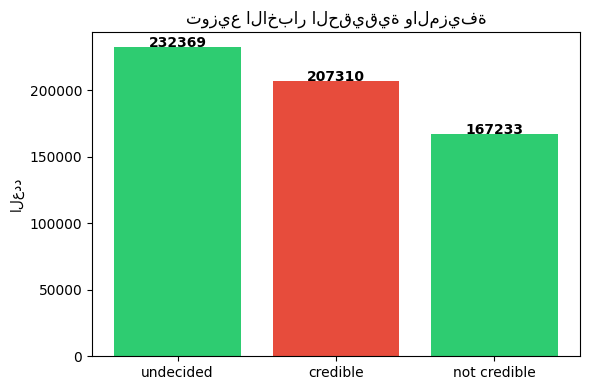


📝 متوسط عدد الكلمات: 244
أطول خبر: 17348 كلمة
أقصر خبر: 2 كلمة


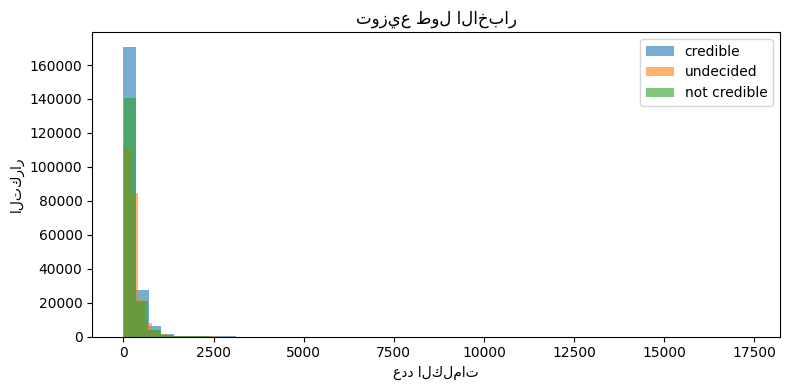

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ===== 1. معلومات أساسية =====
print("📊 معلومات الداتا:")
print(f"عدد الأخبار الكلي: {len(df)}")
print(f"الأعمدة الموجودة: {df.columns.tolist()}")

# ===== 2. توزيع الكلاسات =====
print("\n📈 توزيع الأخبار:")
print(df['label'].value_counts())

# ===== 3. رسم توزيع الأخبار =====
plt.figure(figsize=(6,4))
counts = df['label'].value_counts()
plt.bar(counts.index, counts.values, color=['#2ecc71','#e74c3c'])
plt.title('توزيع الاخبار الحقيقية والمزيفة')
plt.ylabel('العدد')
for i, (label, v) in enumerate(zip(counts.index, counts.values)):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ===== 4. طول النصوص =====
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
print(f"\n📝 متوسط عدد الكلمات: {df['text_length'].mean():.0f}")
print(f"أطول خبر: {df['text_length'].max()} كلمة")
print(f"أقصر خبر: {df['text_length'].min()} كلمة")

# ===== 5. رسم توزيع الطول =====
plt.figure(figsize=(8,4))
for label in df['label'].unique():
    subset = df[df['label'] == label]['text_length']
    plt.hist(subset, bins=50, alpha=0.6, label=str(label))
plt.title('توزيع طول الاخبار')
plt.xlabel('عدد الكلمات')
plt.ylabel('التكرار')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. نأخذ فقط الأخبار المؤكدة (حقيقي أو مزيف)
df_training = df_final[df_final['label'].isin(['credible', 'not credible'])].copy()

# 2. تحويل الكلمات لأرقام (الموديل بيفهم أرقام): الحقيقي = 0 والمزيف = 1
df_training['label_numeric'] = df_training['label'].map({'credible': 0, 'not credible': 1})

# 3. عرض حجم البيانات النهائية
print(f"عدد الأخبار المختارة للتدريب: {len(df_training)}")
print(df_training['label'].value_counts())

df = df_training.copy()
df['label'] = df['label_numeric']

# عرض عينة بسيطة
df_training[['text', 'label_numeric']].head()

عدد الأخبار المختارة للتدريب: 374543
label
credible        207310
not credible    167233
Name: count, dtype: int64


,text,label_numeric
0,اكد الناطق باسم الحكومة وزير الاتصال البروفيسو...,0
1,هذا هو البروتوكول الصحي الخاص بالحملة الإنتخاب...,0
2,أعلنت اليوم السبت وزارة الصحة عن تسجيل 164 إصا...,0
3,ترأس اليوم السبت وزير الشؤون الخارجية، صبري بو...,0
4,برنامج اليوم الرابع من الحملة الانتخابية لتشري...,0


In [ ]:
import re

# دالة لتنظيف النص العربي
def clean_arabic_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = " ".join(text.split())
    return text

# تطبيق التنظيف على عينة من البيانات
df_sample = df_training.sample(n=50000, random_state=42).copy()
df_sample['clean_text'] = df_sample['text'].apply(clean_arabic_text)

df_sample['label'] = df_sample['label_numeric']

print("✅ تم تنظيف عينة من النصوص بنجاح!")
print(f"حجم العينة الحالية: {len(df_sample)}")
df_sample[['clean_text', 'label']].head()



✅ تم تنظيف عينة من النصوص بنجاح!
حجم العينة الحالية: 50000


,clean_text,label
66892,وعد رئيس الحكومة هشام المشيشي خلال لقاءه صباح ...,0
69949,تقدم نادي مانشستر يونايتد بتهنئة خاصة اليوم ال...,0
392480,شبكة عراق الخير أعلنت روسيا السبت أن علماءها ا...,1
242642,وعلق عبر تطبيق تبادل الصور والفيديوانستجرام كل...,0
473275,نفذ عدد من المنضوين تحت التنسيقية الوطنية لإطا...,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import re

# ===== 1. تنظيف النص =====
def clean_text_simple(text):
    text = str(text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)  # خلي بس الحروف العربية
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ===== 2. تجهيز البيانات =====
print("🔄 جاري تجهيز البيانات...")
df_sample = df.sample(n=50000, random_state=42)  # نأخذ 50k عشان ما يبطأ

texts  = df_sample['text'].apply(clean_text_simple).tolist()
labels = df_sample['label'].tolist()

# تقسيم Train/Test
split = int(len(texts) * 0.8)
X_train, X_test = texts[:split], texts[split:]
y_train, y_test = labels[:split], labels[split:]

# ===== 3. TF-IDF =====
print("🔄 جاري حساب TF-IDF...")
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# ===== 4. تدريب Logistic Regression =====
print("🔄 جاري تدريب النموذج...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

# ===== 5. النتائج =====
print("\n📊 نتائج Baseline (TF-IDF + Logistic Regression):")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"F1-Score : {f1_score(y_test, lr_preds, average='weighted'):.4f}")
print("\nتقرير مفصل:")
print(classification_report(y_test, lr_preds,
      target_names=['credible', 'not credible']))

🔄 جاري تجهيز البيانات...
🔄 جاري حساب TF-IDF...
🔄 جاري تدريب النموذج...

📊 نتائج Baseline (TF-IDF + Logistic Regression):
Accuracy : 0.7505
F1-Score : 0.7489

تقرير مفصل:
              precision    recall  f1-score   support

    credible       0.76      0.81      0.78      5579
not credible       0.74      0.67      0.70      4421

    accuracy                           0.75     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.75      0.75     10000



In [ ]:
!pip install transformers[torch] datasets

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "aubmindlab/bert-base-arabertv02"

print("جاري تحميل الـ Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

df_sample2 = df_training.sample(n=50000, random_state=42).copy()
df_sample2['clean_text'] = df_sample2['text'].apply(clean_arabic_text)
df_sample2['label'] = df_sample2['label_numeric']

texts = df_sample2['clean_text'].tolist()
labels = df_sample2['label_numeric'].tolist()

print("✅ تم تحميل الموديل والـ Tokenizer بنجاح!")

جاري تحميل الـ Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ تم تحميل الموديل والـ Tokenizer بنجاح!


In [ ]:
from datasets import Dataset

df_sample2 = df_training.sample(n=50000, random_state=42).copy()
df_sample2['clean_text'] = df_sample2['text'].apply(clean_arabic_text)

df_sample2['labels'] = df_sample2['label_numeric']

dataset = Dataset.from_pandas(df_sample2[['clean_text', 'labels']])

def preprocess_function(examples):
    return tokenizer(examples["clean_text"], truncation=True, padding="max_length", max_length=128)

print("جاري تحويل النصوص إلى أرقام (Tokens)...")
tokenized_dataset = dataset.map(preprocess_function, batched=True)

split_dataset = tokenized_dataset.train_test_split(test_size=0.2)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

print("✅ البيانات جاهزة للتدريب الآن!")
print(f"عدد أخبار التدريب: {len(train_dataset)}")
print(f"عدد أخبار الاختبار: {len(test_dataset)}")

جاري تحويل النصوص إلى أرقام (Tokens)...


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ البيانات جاهزة للتدريب الآن!
عدد أخبار التدريب: 40000
عدد أخبار الاختبار: 10000


In [ ]:
!pip install evaluate -q

from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification
import numpy as np
import evaluate

# 1. تحميل الموديل
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. تعريف دالة قياس الدقة
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 3. إعدادات التدريب
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# 4. تجهيز المدرب
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 5. انطلاق التدريب 🚀
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy
1,0.302967,0.332367,0.837000
2,0.239282,0.299549,0.859100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5000, training_loss=0.3376229541778564, metrics={'train_runtime': 2256.4353, 'train_samples_per_second': 35.454, 'train_steps_per_second': 2.216, 'total_flos': 5262221107200000.0, 'train_loss': 0.3376229541778564, 'epoch': 2.0})

🔄 جاري تقييم AraBERT...


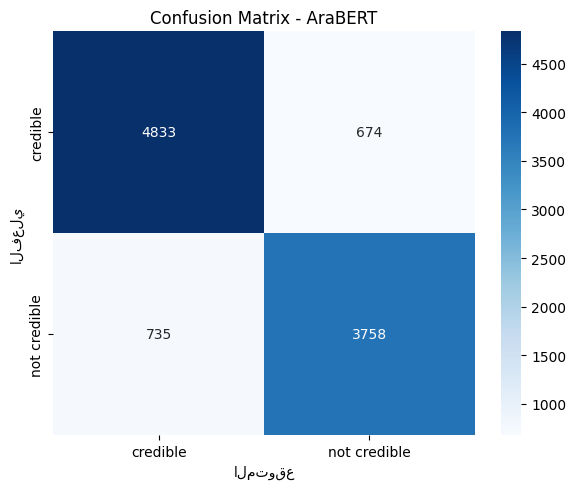


📊 نتائج AraBERT:
              precision    recall  f1-score   support

    credible       0.87      0.88      0.87      5507
not credible       0.85      0.84      0.84      4493

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


🏆 مقارنة النماذج:
النموذج                             Accuracy        F1-Score
------------------------------------------------------------
TF-IDF + Logistic Regression        0.7505          0.7489
AraBERT (Fine-tuned)                0.8591          0.8590


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

# ===== تقييم AraBERT =====
print("🔄 جاري تقييم AraBERT...")
predictions_output = trainer.predict(test_dataset)
arabert_preds = np.argmax(predictions_output.predictions, axis=1)
arabert_labels = predictions_output.label_ids

# Confusion Matrix
cm = confusion_matrix(arabert_labels, arabert_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['credible', 'not credible'],
            yticklabels=['credible', 'not credible'])
plt.title('Confusion Matrix - AraBERT')
plt.ylabel('الفعلي')
plt.xlabel('المتوقع')
plt.tight_layout()
plt.show()

# تقرير مفصل
print("\n📊 نتائج AraBERT:")
print(classification_report(arabert_labels, arabert_preds,
      target_names=['credible', 'not credible']))

# مقارنة النموذجين
print("\n🏆 مقارنة النماذج:")
print(f"{'النموذج':<35} {'Accuracy':<15} {'F1-Score'}")
print("-"*60)
print(f"{'TF-IDF + Logistic Regression':<35} {accuracy_score(y_test, lr_preds):<15.4f} {f1_score(y_test, lr_preds, average='weighted'):.4f}")
print(f"{'AraBERT (Fine-tuned)':<35} {accuracy_score(arabert_labels, arabert_preds):<15.4f} {f1_score(arabert_labels, arabert_preds, average='weighted'):.4f}")

In [ ]:
def predict_news(text):
    # تنظيف النص بنفس الطريقة
    cleaned_text = clean_arabic_text(text)
    # تحويل النص لأرقام
    inputs = tokenizer(cleaned_text, return_tensors="pt", truncation=True, padding=True, max_length=128).to("cuda")
    # التنبؤ
    outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=-1)
    prediction = np.argmax(probs.detach().cpu().numpy())

    labels_map = {0: "خبر حقيقي ✅", 1: "خبر مزيف/مضلل ❌"}
    return labels_map[prediction]

news_to_test = "اكتشاف لقاح جديد يعالج جميع أنواع السرطان في يوم واحد"
print(f"نتيجة الفحص: {predict_news(news_to_test)}")

نتيجة الفحص: خبر مزيف/مضلل ❌


In [ ]:
import torch

def check_news(news_text):
    # 1. تجهيز النص (التنظيف والتحويل لأرقام)
    inputs = tokenizer(news_text, return_tensors="pt", truncation=True, padding=True, max_length=128).to("cuda")

    # 2. تمرير النص للموديل
    model.eval() # وضعية القراءة فقط
    with torch.no_grad():
        outputs = model(**inputs)

    # 3. حساب الاحتمالات
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probs, dim=-1).item()
    confidence = torch.max(probs).item() * 100

    # 4. النتيجة النهائية
    if prediction == 0:
        return f"✅ الخبر: [حقيقي] - نسبة الثقة: {confidence:.2f}%"
    else:
        return f"❌ الخبر: [مزيف/مضلل] - نسبة الثقة: {confidence:.2f}%"

test_1 = "وزارة التعليم تعلن تأجيل الامتحانات النهائية لمدة أسبوع"
test_2 = "اكتشاف كائن فضائي يعيش في غابات جرش"

print("اختبار 1:", check_news(test_1))
print("اختبار 2:", check_news(test_2))

اختبار 1: ✅ الخبر: [حقيقي] - نسبة الثقة: 90.05%
اختبار 2: ❌ الخبر: [مزيف/مضلل] - نسبة الثقة: 94.22%


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/ArabicFN_Model'

# 3. حفظ الموديل والـ Tokenizer
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"✅ تم حفظ الموديل بنجاح في مجلد: {save_path}")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ تم حفظ الموديل بنجاح في مجلد: /content/drive/MyDrive/ArabicFN_Model


أولاً: أخبار مزيفة/مضللة (إشاعات) ❌
"عاجل: إلغاء الفصل الدراسي الثاني لجميع الجامعات الأردنية وتحويلها لتعليم عن بعد."

"اكتشاف بئر نفط في منطقة صويلح يكفي الأردن لمدة 100 عام."

"دراسة يابانية: النوم أثناء العمل يزيد من نسبة الذكاء بمعدل 40%."

"ناسا تعلن اكتشاف مدينة ذهبية تحت سطح المريخ."

"الديوان الملكي يعلن عن مكرمة ملكية بتوزيع لابتوب مجاني لكل طالب جامعة."

"تحذير من عاصفة ثلجية قادمة الأسبوع القادم ستغلق جميع طرق المملكة."

"شركة واتساب ستبدأ بفرض رسوم شهرية قيمتها 10 دنانير على المشتركين."

"علماء يكتشفون علاجاً نهائياً للسكري باستخدام ورق الزيتون فقط في يومين."

"إغلاق جميع محطات الوقود في الأردن ابتداءً من يوم الغد وحتى إشعار آخر."

"تغيير دوام الموظفين في القطاع العام ليصبح من الساعة 10 صباحاً حتى 2 ظهراً."





ثانياً: أخبار حقيقية (من وكالات الأنباء) ✅
"أعلنت وزارة التربية والتعليم عن جدول امتحانات الثانوية العامة للدورة الصيفية."

"انخفاض أسعار المحروقات في الأردن بنسب متفاوتة لشهر أيار الحالي."

"جامعة اليرموك تحتفل بتخريج فوج جديد من طلبة كلية تكنولوجيا المعلومات."

"وزير الصحة يفتتح مركزاً صحياً جديداً في محافظة إربد لخدمة المجتمع المحلي."

"المنتخب الوطني لكرة القدم يتقدم 5 مراكز في تصنيف الفيفا العالمي."

"البنك المركزي الأردني يقرر تثبيت أسعار الفائدة تماشياً مع الأوضاع الاقتصادية."

"توقيع اتفاقية تعاون بين الأردن وألمانيا لتعزيز مشاريع الطاقة المتجددة."

"الأمانة تعلن عن خطة جديدة لتطوير شبكة النقل العام في العاصمة عمان."

"ارتفاع صادرات الأردن من المنتجات الزراعية إلى الأسواق الأوروبية هذا العام."

"انطلاق فعاليات مهرجان جرش للثقافة والفنون بمشاركة فرق فنية عالمية."